In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\iago_\hipermercado_projeto\dataset\superstore_data.csv')
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.columns = df.columns.str.lower()

df['dt_customer'] = pd.to_datetime(df['dt_customer'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2216 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

In [5]:
df.isna().sum()
#coluna income com 24 valores ausentes

id                      0
year_birth              0
education               0
marital_status          0
income                 24
kidhome                 0
teenhome                0
dt_customer             0
recency                 0
mntwines                0
mntfruits               0
mntmeatproducts         0
mntfishproducts         0
mntsweetproducts        0
mntgoldprods            0
numdealspurchases       0
numwebpurchases         0
numcatalogpurchases     0
numstorepurchases       0
numwebvisitsmonth       0
response                0
complain                0
dtype: int64

In [6]:
df['income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: income, dtype: float64

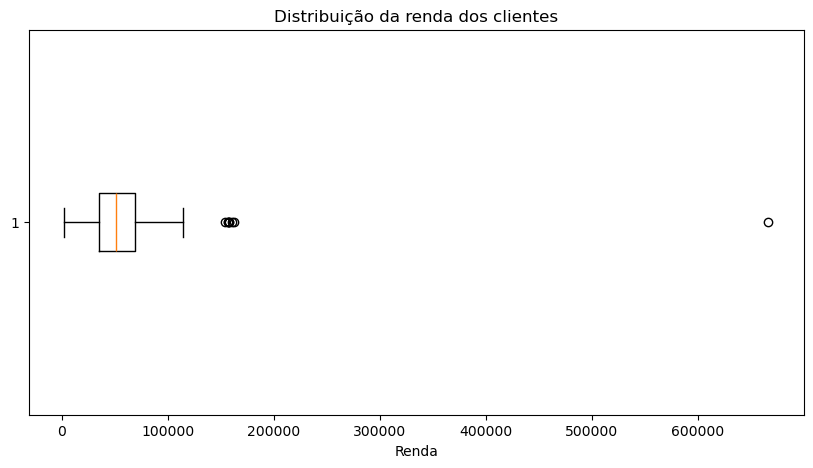

In [7]:
import seaborn as sns
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(df['income'].dropna(), vert=False)

plt.title('Distribuição da renda dos clientes')
plt.xlabel('Renda')

plt.show()

*Valores Atipicos na coluna Income*

Indetifiquei valores atipicos na coluna income e temos 24 valores ausentes por mais que a media e a mediana possuam valores proximos irei optar pelo preenchimento com a mediana 
pois é uma medida menos sensivel a valores extremos. 

In [8]:
df['income'] = df['income'].fillna(df['income'].median())
#estou acessando a coluna do df e substituindo os valores ausentes usando o metodo fillna() com a mediana da coluna income.

In [9]:
df['income'].isna().sum()

np.int64(0)

In [10]:
renda_alta = 0

for renda in df['income']:
    if renda >= 200000:
        renda_alta += 1

print(renda_alta)

1


In [11]:
renda_alta_2 = 0

for renda in df['income']:
    if renda >= 125000:
        renda_alta_2 += 1

print(renda_alta_2)

8


In [12]:
print('Média com o outlier:')
print(df['income'].mean())

print('\nMédia sem o cliente de income 666666:')
print(df[df['income'] < 200000]['income'].mean())

print('\nMediana:')
print(df['income'].median())

Média com o outlier:
52237.97544642857

Média sem o cliente de income 666666:
51963.55471192497

Mediana:
51381.5


In [13]:
df = df[df['income'] != 666666].copy()
df['income'].max()
#criando um df em que na coluna income estejam todos os valores diferentes de 666666.

162397.0

Foi identificado um valor de renda de 666.666, muito distante dos demais valores da distribuição. Apesar de seu impacto sobre a média geral ser pequeno, o registro foi considerado um valor extremo e removido para evitar possíveis distorções nas etapas posteriores da análise e modelagem. Os demais valores elevados foram mantidos por serem considerados plausíveis.

In [14]:
print(df.duplicated().sum())
#checando valores duplicados

0


In [15]:
df['age'] = 2026 - df['year_birth']
print(df['age'].head())

0    56
1    65
2    68
3    59
4    37
Name: age, dtype: int64


In [16]:
nao_aderiram = df[df['response'] == 0]
print(nao_aderiram.head(3))

      id  year_birth   education marital_status   income  kidhome  teenhome  \
2  10476        1958  Graduation        Married  67267.0        0         1   
3   1386        1967  Graduation       Together  32474.0        1         1   
7   1991        1967  Graduation       Together  44931.0        0         1   

  dt_customer  recency  mntwines  ...  mntsweetproducts  mntgoldprods  \
2  2014-05-13        0       134  ...                 2            30   
3  2014-11-05        0        10  ...                 0             0   
7  2014-01-18        0        78  ...                 0             7   

   numdealspurchases  numwebpurchases  numcatalogpurchases  numstorepurchases  \
2                  1                3                    2                  5   
3                  1                1                    0                  2   
7                  1                2                    1                  3   

   numwebvisitsmonth  response  complain  age  
2                

In [17]:
nao_aderiram['education'].value_counts()

education
Graduation    974
PhD           385
Master        313
2n Cycle      181
Basic          52
Name: count, dtype: int64

In [18]:
aderiram = df[df['response'] == 1]

idade_media_0 = nao_aderiram['age'].mean().round()
idade_media_1 = aderiram['age'].mean().round()
print(f'Idade média dos clientes que não foram a favor da campanha: {idade_media_0}')
print()
print(f'Idade média dos clientes que foram a favor da campanha: {idade_media_1}')

Idade média dos clientes que não foram a favor da campanha: 57.0

Idade média dos clientes que foram a favor da campanha: 57.0


In [19]:
print(nao_aderiram['kidhome'].value_counts())
nao_aderiram['teenhome'].value_counts()

kidhome
0    1071
1     788
2      46
Name: count, dtype: int64


teenhome
1    938
0    920
2     47
Name: count, dtype: int64

In [20]:
df['dependents'] = df['kidhome'] + df['teenhome']
df[['kidhome', 'teenhome', 'dependents']].head()

,kidhome,teenhome,dependents
0,0,0,0
1,0,0,0
2,0,1,1
3,1,1,2
4,1,0,1


In [21]:
def family_profile(row):
    if row['kidhome'] == 0 and row['teenhome'] == 0:
        return 'Sem dependentes'
    elif row['kidhome'] > 0 and row['teenhome'] == 0:
        return 'Somente crianças'
    elif row['kidhome'] == 0 and row['teenhome'] > 0:
        return 'Somente adolescentes'
    else:
        return 'Crianças e adolescentes'
    

df['family_profile'] = df.apply(family_profile, axis=1)
df['family_profile'].value_counts()
#criando uma função para termos o perfil da familia dos clientes

family_profile
Somente adolescentes       655
Sem dependentes            638
Somente crianças           519
Crianças e adolescentes    427
Name: count, dtype: int64

In [22]:
nao_aderiram['family_profile'] = nao_aderiram.apply(family_profile, axis=1)
nao_aderiram['family_profile'].value_counts()

C:\Users\iago_\AppData\Local\Temp\ipykernel_12220\3026975924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nao_aderiram['family_profile'] = nao_aderiram.apply(family_profile, axis=1)


family_profile
Somente adolescentes       602
Sem dependentes            469
Somente crianças           451
Crianças e adolescentes    383
Name: count, dtype: int64

In [23]:
aderiram['family_profile'] = aderiram.apply(family_profile, axis=1)
aderiram['family_profile'].value_counts()

C:\Users\iago_\AppData\Local\Temp\ipykernel_12220\2617080179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aderiram['family_profile'] = aderiram.apply(family_profile, axis=1)


family_profile
Sem dependentes            169
Somente crianças            68
Somente adolescentes        53
Crianças e adolescentes     44
Name: count, dtype: int64

In [24]:
df['response'].value_counts()

response
0    1905
1     334
Name: count, dtype: int64

O dado bruto já sugere algo interessante: entre quem aderiu, 169 de 334 não têm dependentes, cerca de 50,6%. Entre quem não aderiu, são 469 de 1.905, cerca de 24,6%. Essa diferença é grande.

### Situação civil, renda e adesão à campanha

A tabela apresenta a quantidade de clientes, a renda média e a renda mediana para cada combinação de situação civil e resposta à campanha.

In [25]:
resumo_renda_civil = (
    df.groupby(['marital_status', 'response'])
      .agg(
          quantidade_clientes=('id', 'size'),
          renda_media=('income', 'mean'),
          renda_mediana=('income', 'median')
      )
      .reset_index()
      .sort_values(['marital_status', 'response'])
)

resumo_renda_civil['renda_media'] = resumo_renda_civil['renda_media'].round(2)
resumo_renda_civil['renda_mediana'] = resumo_renda_civil['renda_mediana'].round(2)
resumo_renda_civil['response'] = resumo_renda_civil['response'].map({
    0: 'Não aderiram',
    1: 'Aderiram'
})

resumo_renda_civil

,marital_status,response,quantidade_clientes,renda_media,renda_mediana
0,Absurd,Não aderiram,1,65487.00,65487.0
1,Absurd,Aderiram,1,79244.00,79244.0
2,Alone,Não aderiram,2,47753.50,47753.5
3,Alone,Aderiram,1,35860.00,35860.0
4,Divorced,Não aderiram,184,50525.97,50306.5
5,Divorced,Aderiram,48,61682.56,64318.5
6,Married,Não aderiram,766,50633.19,51025.5
7,Married,Aderiram,98,60234.26,63091.5
8,Single,Não aderiram,374,48299.88,47757.0
9,Single,Aderiram,106,60538.58,66487.5


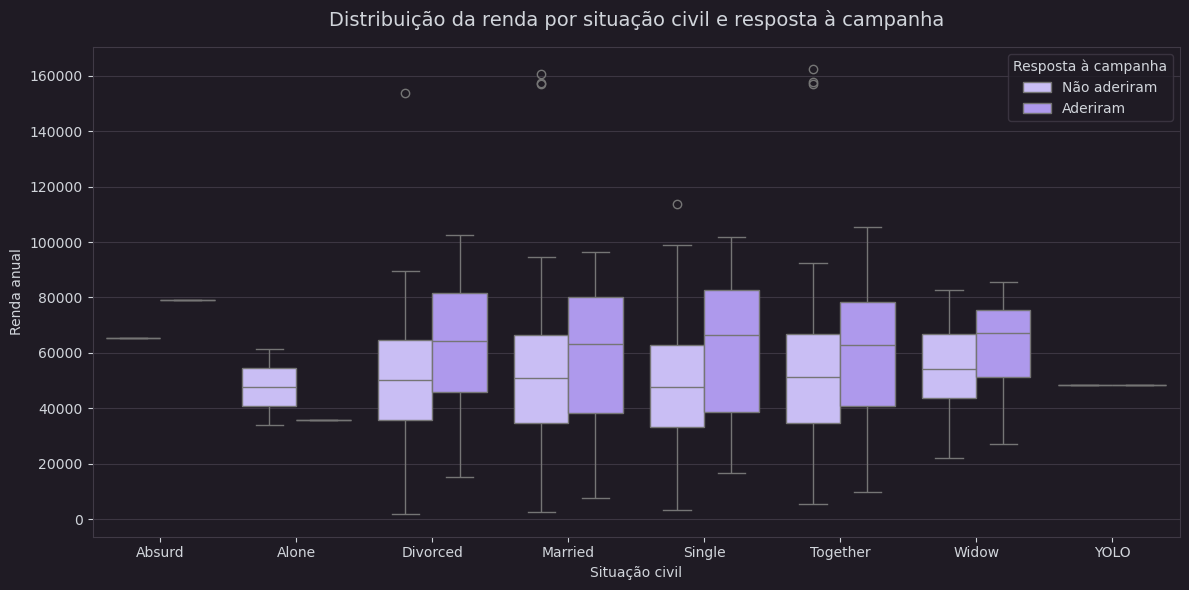

In [26]:
dados_boxplot = df.assign(
    resposta_campanha=df['response'].map({
        0: 'Não aderiram',
        1: 'Aderiram'
    })
)

ordem_situacao_civil = sorted(df['marital_status'].unique())

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#1f1b24')
ax.set_facecolor('#1f1b24')

sns.boxplot(
    data=dados_boxplot,
    x='marital_status',
    y='income',
    hue='resposta_campanha',
    order=ordem_situacao_civil,
    hue_order=['Não aderiram', 'Aderiram'],
    palette={'Não aderiram': '#c4b5fd', 'Aderiram': '#a78bfa'},
    ax=ax
)

ax.set_title(
    'Distribuição da renda por situação civil e resposta à campanha',
    color='#d1d5db',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Situação civil', color='#d1d5db')
ax.set_ylabel('Renda anual', color='#d1d5db')
ax.tick_params(colors='#d1d5db')
ax.yaxis.grid(True, color='#403a46', linewidth=0.8, alpha=0.9)
ax.xaxis.grid(False)

legenda = ax.legend(title='Resposta à campanha')
legenda.get_frame().set_facecolor('#1f1b24')
legenda.get_frame().set_edgecolor('#403a46')
plt.setp(legenda.get_texts(), color='#d1d5db')
legenda.get_title().set_color('#d1d5db')

for borda in ax.spines.values():
    borda.set_color('#403a46')

plt.tight_layout()
plt.show()